# Certified Counterfactual Generation on MNIST

This notebook demonstrates the **CertCFAtlas** API on a real image dataset (MNIST).

Unlike the 2D spiral example, here we work in **784 dimensions** (28x28 pixels), so:
- Polytope visualization is replaced by **image-space** visualization
- We use L∞ perturbation norm (standard for image robustness)
- QP projection is more expensive, but BVH pruning keeps it tractable

Key features demonstrated:
1. **Certified counterfactuals** on a CNN classifier
2. **δ-robust counterfactuals** with configurable robustness norm
3. **BVH vs k-NN** efficiency comparison in high dimensions

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import TensorDataset

import sys
sys.path.insert(0, '../src')
from models.classifiers import MNISTClassifier
from certcf import CertCFAtlas

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

## 2 – Load Data & Model

We load the MNIST test set and select a subset of samples per class to keep computation tractable.

In [ ]:
test_transform = transforms.Compose([
    transforms.ToTensor(),
])
full_test = datasets.MNIST(root='../data', train=False, download=True, transform=test_transform)

# Select a balanced subset (N_PER_CLASS samples per digit)
N_PER_CLASS = 2000
targets = full_test.targets.numpy()

indices = []
for c in range(10):
    class_idx = np.where(targets == c)[0][:N_PER_CLASS]
    indices.extend(class_idx)

# Materialize transformed images into a TensorDataset
images = torch.stack([full_test[i][0] for i in indices])
labels = torch.tensor([full_test[i][1] for i in indices])
dataset = TensorDataset(images, labels)

print(f'Dataset: {len(dataset)} samples ({N_PER_CLASS} per class), shape: {images.shape}')

# Load pre-trained CNN from Lightning checkpoint
from training.lit_classifier import LitClassifier
lit = LitClassifier.load_from_checkpoint(
    '../checkpoints/classifier/MNIST-Classifier-032-0.0144.ckpt',
    model=MNISTClassifier(num_classes=10)
)
model = lit.model.to(device).eval()

# Verify accuracy
with torch.no_grad():
    preds = model(images.to(device)).argmax(dim=1).cpu()
    acc = (preds == labels).float().mean()
print(f'Model accuracy on subset: {acc*100:.1f}%')

## 3 – Build Certified Atlas

We use L∞ norm with `eps=0.01` (in normalized pixel space). This is the standard threat model for MNIST robustness.

Note: `cnn=True` tells the atlas to reshape flattened vectors back to `(1, 28, 28)` for the model.

In [19]:
atlas = CertCFAtlas(model, dataset, device, cnn=True, solver_maxiter=3000)

atlas.build(
    eps=0.4,
    # norm=np.inf,
    norm=1,
    batch_size=20,
    verbose=True
)

Building certified atlas (eps=0.4, L1 norm)...
  Computing LiRPA bounds...


Computing bounds:   0%|          | 0/10 [00:00<?, ?it/s]/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/auto_LiRPA/perturbations.py:199: RuntimeWarning: divide by zero encountered in scalar divide
  self.dual_norm = 1 if (norm == np.inf) else (np.float64(1.0) / (1 - 1.0 / self.norm))
Computing bounds: 100%|██████████| 10/10 [01:29<00:00,  8.93s/it]

  Building BVH spatial indices...
    Class 0: 980 polytopes, tree depth 11
    Class 1: 1135 polytopes, tree depth 12
    Class 2: 1032 polytopes, tree depth 12
    Class 3: 1010 polytopes, tree depth 11
    Class 4: 982 polytopes, tree depth 11
    Class 5: 892 polytopes, tree depth 11
    Class 6: 958 polytopes, tree depth 11
    Class 7: 1028 polytopes, tree depth 12
    Class 8: 974 polytopes, tree depth 11
    Class 9: 1009 polytopes, tree depth 11
Done! Total: 10000 polytopes across 10 classes


CertCFAtlas(n_classes=10, built)

In [20]:
print(atlas.summary())

CertCFAtlas Summary
Classes: 10
Perturbation: eps=0.4, L1 norm
Device: cuda

  Class 0:  980 polytopes (BVH depth 11)
  Class 1: 1135 polytopes (BVH depth 12)
  Class 2: 1032 polytopes (BVH depth 12)
  Class 3: 1010 polytopes (BVH depth 11)
  Class 4:  982 polytopes (BVH depth 11)
  Class 5:  892 polytopes (BVH depth 11)
  Class 6:  958 polytopes (BVH depth 11)
  Class 7: 1028 polytopes (BVH depth 12)
  Class 8:  974 polytopes (BVH depth 11)
  Class 9: 1009 polytopes (BVH depth 11)

Total polytopes: 10000


In [21]:
# Check polytope feasibility across all classes
print('Polytope feasibility analysis:\n')

total_feasible = 0
total = 0
for label in range(10):
    bd = atlas.bounds[label]
    n = len(bd['X'])
    feasible = 0
    for i in range(n):
        margins = bd['lA'][i] @ bd['X'][i] + bd['lbias'][i]
        if margins.min() >= -1e-6:
            feasible += 1
    total_feasible += feasible
    total += n
    print(f'  Digit {label}: {feasible}/{n} polytopes feasible ({100*feasible/n:.0f}%)')

print(f'\nTotal: {total_feasible}/{total} ({100*total_feasible/total:.0f}%)')

Polytope feasibility analysis:

  Digit 0: 0/980 polytopes feasible (0%)
  Digit 1: 0/1135 polytopes feasible (0%)
  Digit 2: 0/1032 polytopes feasible (0%)
  Digit 3: 0/1010 polytopes feasible (0%)
  Digit 4: 0/982 polytopes feasible (0%)
  Digit 5: 0/892 polytopes feasible (0%)
  Digit 6: 0/958 polytopes feasible (0%)
  Digit 7: 0/1028 polytopes feasible (0%)
  Digit 8: 0/974 polytopes feasible (0%)
  Digit 9: 0/1009 polytopes feasible (0%)

Total: 0/10000 (0%)


/tmp/ipykernel_43063/638372270.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7, ncol=2)


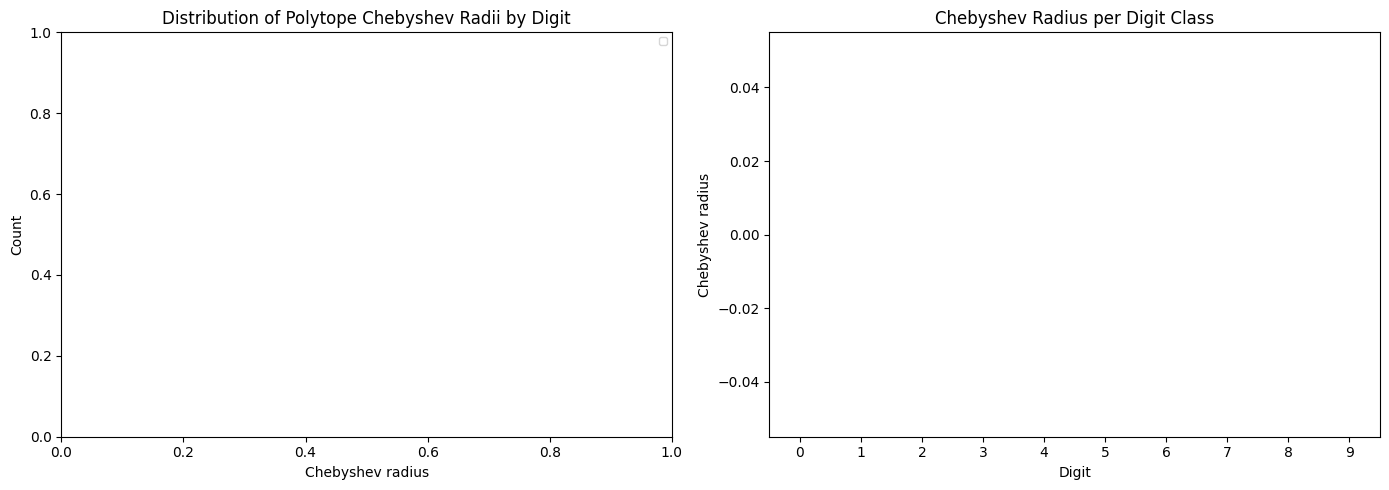

Feasible polytopes: 0/10000


/tmp/ipykernel_43063/638372270.py:59: RuntimeWarning: Mean of empty slice
  print(f'Chebyshev radius: mean={all_flat.mean():.4f}, median={np.median(all_flat):.4f}, '
/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,


ValueError: zero-size array to reduction operation minimum which has no identity

In [22]:
# Polytope size distribution via Chebyshev radius
# In 784D, volume is intractable. The Chebyshev radius r = min_i (a_i^T c + b_i) / ||a_i||_2
# is the radius of the largest L2-ball centered at c that fits inside the halfspace constraints.
# The box/ball constraint further caps r at eps.

all_radii = {}
for label in range(10):
    bd = atlas.bounds[label]
    radii = []
    for i in range(len(bd['X'])):
        margins = bd['lA'][i] @ bd['X'][i] + bd['lbias'][i]
        if margins.min() < -1e-6:
            continue  # infeasible
        row_norms = np.linalg.norm(bd['lA'][i], axis=1, ord=2)
        row_norms = np.maximum(row_norms, 1e-12)
        r = np.min(margins / row_norms)
        r = min(r, atlas.eps)  # capped by the ball/box constraint
        radii.append(r)
    all_radii[label] = np.array(radii)

cmap = plt.colormaps.get_cmap('tab10')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overlaid histogram
ax = axes[0]
for label in range(10):
    if len(all_radii[label]) > 0:
        ax.hist(all_radii[label], bins=30, alpha=0.4, color=cmap(label),
                label=f'{label} (n={len(all_radii[label])})')
ax.set_xlabel('Chebyshev radius')
ax.set_ylabel('Count')
ax.set_title('Distribution of Polytope Chebyshev Radii by Digit')
ax.legend(fontsize=7, ncol=2)
ax.set_xlim(left=0)

# Box plot
ax = axes[1]
data = [all_radii[l] for l in range(10)]
bp = ax.boxplot(
    data,
    tick_labels=[str(l) for l in range(10)],
    patch_artist=True
)
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor(cmap(i))
    patch.set_alpha(0.6)
ax.set_xlabel('Digit')
ax.set_ylabel('Chebyshev radius')
ax.set_title('Chebyshev Radius per Digit Class')

plt.tight_layout()
plt.show()

# Summary
all_flat = np.concatenate(list(all_radii.values()))
total = sum(len(r) for r in all_radii.values())
print(f'Feasible polytopes: {total}/10000')
print(f'Chebyshev radius: mean={all_flat.mean():.4f}, median={np.median(all_flat):.4f}, '
      f'min={all_flat.min():.4f}, max={all_flat.max():.4f}')
print(f'Polytopes at max radius (eps={atlas.eps}): '
      f'{np.sum(np.isclose(all_flat, atlas.eps, atol=1e-6))}/{total}')

## 4 – Visualize Dataset Samples

Let's look at some of the MNIST digits we'll be generating counterfactuals for.

In [ ]:
def denormalize(x_flat):
    """Reshape flat vector to displayable 28x28 image."""
    return np.clip(x_flat.reshape(28, 28), 0, 1)

fig, axes = plt.subplots(2, 10, figsize=(15, 3.5))
for digit in range(10):
    X_digit = atlas.bounds[digit]['X']
    for row in range(2):
        ax = axes[row, digit]
        ax.imshow(denormalize(X_digit[row]), cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
        if row == 0:
            ax.set_title(str(digit), fontsize=12)

fig.suptitle('MNIST Samples (2 per class)', fontsize=14)
plt.tight_layout()
plt.show()

## 5 – Generate Counterfactuals

For selected query digits, we find the closest certified counterfactual for each target class.

Given a query point $\mathbf{x}_0$ classified as class $s$, we seek the nearest point that is **certifiably** classified as a target class $t$. The offline phase constructs, for each training sample $\mathbf{c}_i$ of class $t$, a certified polytope

$$\mathcal{P}_i = \left\{ \mathbf{x} \;:\; A_i \mathbf{x} + \mathbf{b}_i \geq \mathbf{0} \right\} \;\cap\; \mathcal{B}_p(\mathbf{c}_i, \varepsilon)$$

where $A_i, \mathbf{b}_i$ are linear lower bounds from LiRPA satisfying $A_i \mathbf{x} + \mathbf{b}_i \leq f_t(\mathbf{x}) - f_j(\mathbf{x})$ for all $j \neq t$, and $\mathcal{B}_p(\mathbf{c}_i, \varepsilon) = \{\mathbf{x} : \|\mathbf{x} - \mathbf{c}_i\|_p \leq \varepsilon\}$ is the $L_p$ ball within which the bounds are valid.

Every point inside $\mathcal{P}_i$ is **guaranteed** to be classified as class $t$.

The online phase solves, for each candidate polytope $\mathcal{P}_i$:

$$\min_{\mathbf{x}} \;\|\mathbf{x} - \mathbf{x}_0\|_2^2 \qquad \text{s.t.} \quad A_i \mathbf{x} + \mathbf{b}_i \geq \mathbf{0}, \quad \|\mathbf{x} - \mathbf{c}_i\|_p \leq \varepsilon$$

and returns the projection with minimum distance across all polytopes of class $t$. This is a convex QP (quadratic objective with linear + $L_p$-ball constraints), so each projection yields a global optimum. A BVH spatial index prunes polytopes whose bounding box is farther than the current best, achieving $O(\log N)$ QP solves on average.

In [9]:
source_class = 1
n_queries = 3
query_points = atlas.bounds[source_class]['X'][:n_queries]

print(f'Generating counterfactuals for {n_queries} queries from digit {source_class}\n')

all_results = {}
for target_class in range(10):
    if target_class == source_class:
        continue

    results = []
    for i, x0 in enumerate(query_points):
        result = atlas.find_counterfactual(x0, target_class, method='bvh')
        results.append(result)

    all_results[target_class] = results
    n_ok = sum(r.success for r in results)
    avg_dist = np.mean([r.distance for r in results if r.success]) if n_ok > 0 else float('inf')
    avg_qp = np.mean([r.n_qp_solved for r in results])
    print(f'  -> Digit {target_class}: {n_ok}/{n_queries} success, '
          f'avg dist={avg_dist:.2f}, avg QPs={avg_qp:.1f}')

Generating counterfactuals for 3 queries from digit 1

  -> Digit 0: 3/3 success, avg dist=26.20, avg QPs=2.0
  -> Digit 2: 3/3 success, avg dist=19.85, avg QPs=1.3
  -> Digit 3: 3/3 success, avg dist=20.05, avg QPs=2.7
  -> Digit 4: 3/3 success, avg dist=18.54, avg QPs=1.3
  -> Digit 5: 3/3 success, avg dist=19.93, avg QPs=1.0
  -> Digit 6: 3/3 success, avg dist=20.62, avg QPs=2.3
  -> Digit 7: 3/3 success, avg dist=14.98, avg QPs=1.3
  -> Digit 8: 3/3 success, avg dist=20.41, avg QPs=2.7
  -> Digit 9: 3/3 success, avg dist=18.62, avg QPs=1.0


## 6 – Verify Counterfactuals

All counterfactuals lie inside certified polytopes, so they are **guaranteed** to be classified correctly.

In [10]:
print('Verifying counterfactual validity:\n')

all_valid = True
for target_class, results in all_results.items():
    for i, result in enumerate(results):
        if not result.success:
            all_valid = False
            continue
        verification = atlas.verify_counterfactual(result.x_cf, target_class)
        if not verification['valid']:
            print(f'  INVALID: query {i} -> digit {target_class}, '
                  f'pred={verification["predicted"]}')
            all_valid = False

print(f'All counterfactuals valid: {all_valid}')

Verifying counterfactual validity:

All counterfactuals valid: True


## 7 – Counterfactual Interpolation Paths

For each target class, we show the linear interpolation $\mathbf{x}(\alpha) = (1-\alpha)\,\mathbf{x}_0 + \alpha\,\mathbf{x}_{cf}$ from the original digit to the counterfactual. The predicted digit at each step is shown in the corner (green = target class reached).

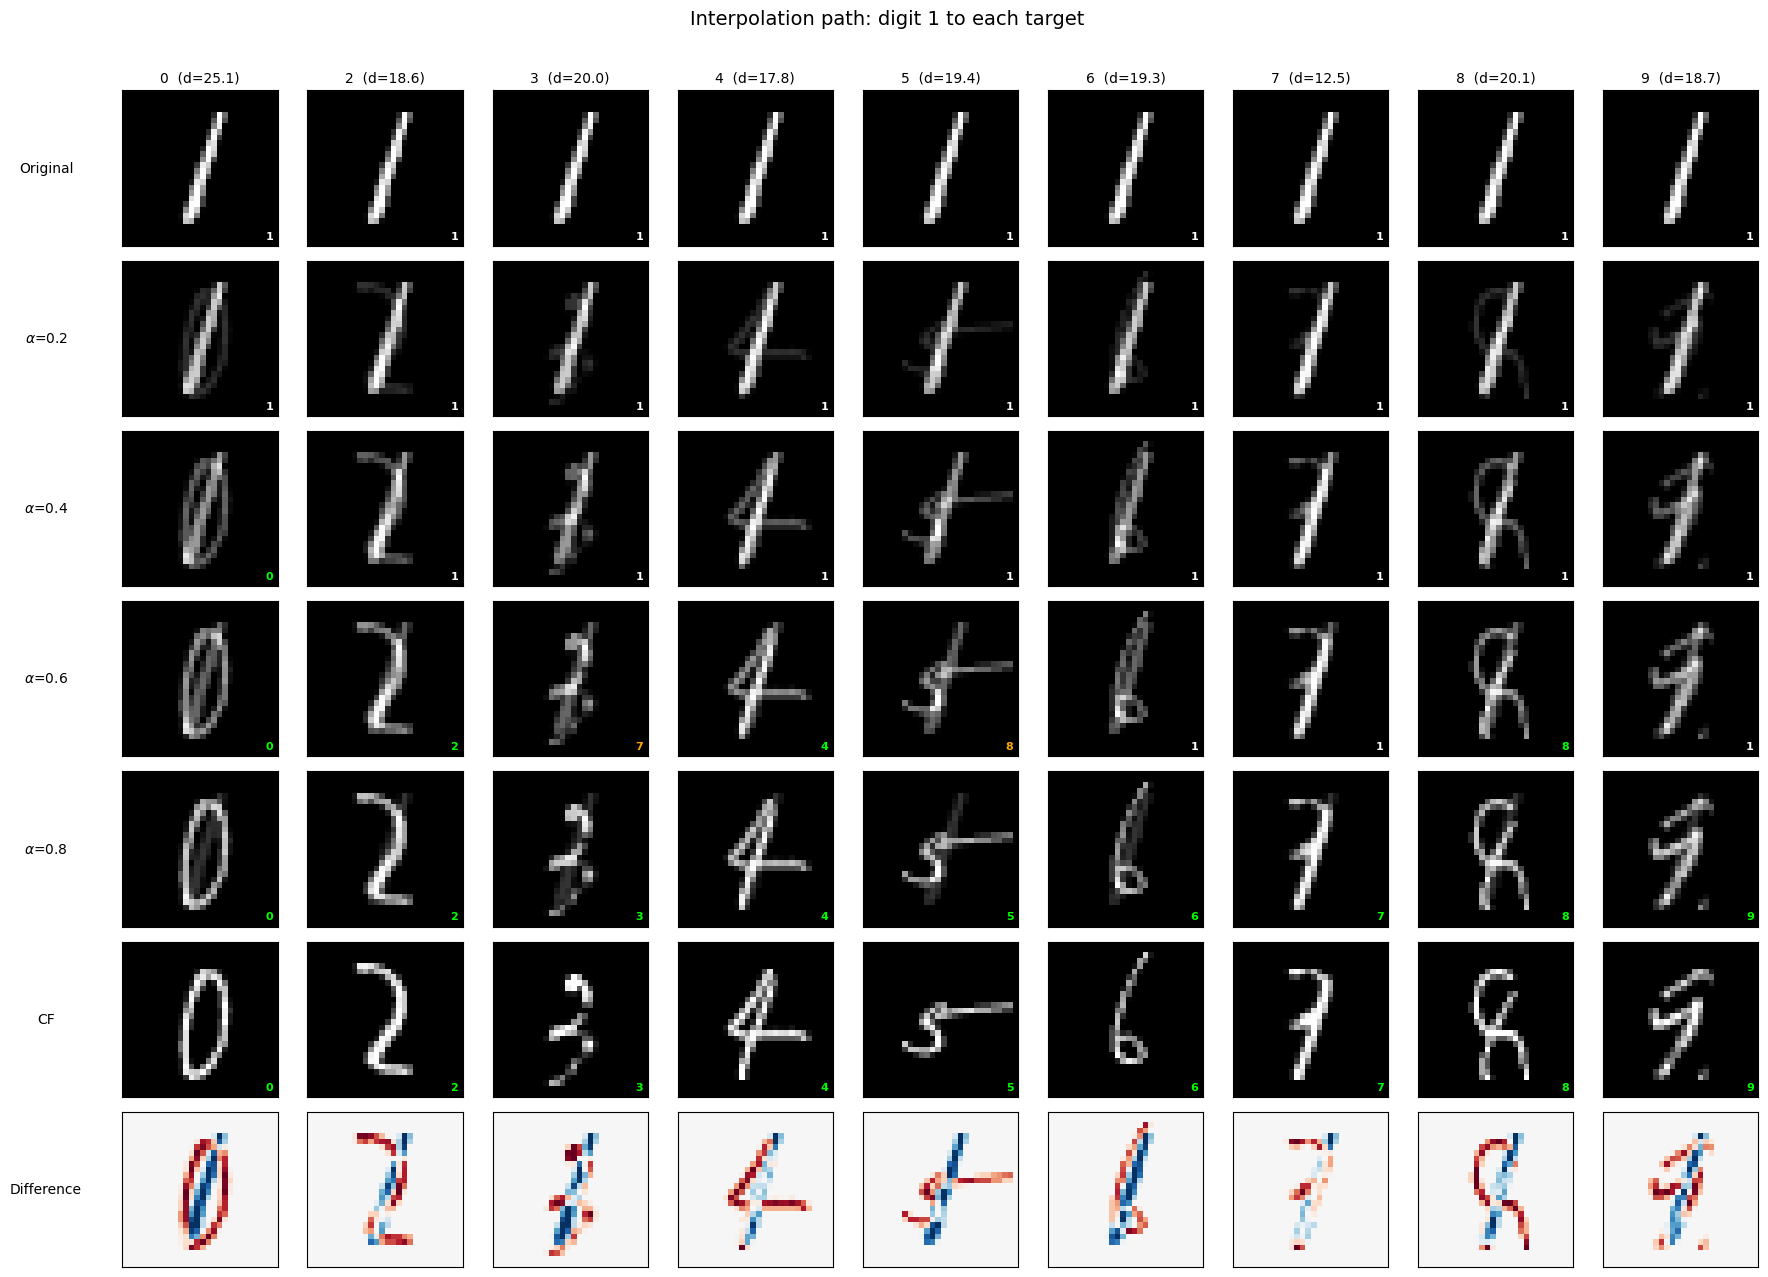

In [11]:
query_idx = 0
x_orig = query_points[query_idx]

target_classes = sorted(all_results.keys())
n_targets = len(target_classes)

# Interpolation steps
alphas = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
n_steps = len(alphas)
n_rows = n_steps + 1  # +1 for difference map

fig, axes = plt.subplots(n_rows, n_targets, figsize=(2 * n_targets, 1.8 * n_rows))

# Row labels
row_labels = [f'$\\alpha$={a:.1f}' for a in alphas] + ['Difference']
row_labels[0] = 'Original'
row_labels[-2] = 'CF'
for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(label, fontsize=10, rotation=0, labelpad=55, va='center')

for col, target_class in enumerate(target_classes):
    result = all_results[target_class][query_idx]

    if not result.success:
        axes[0, col].set_title(f'{target_class}\n(failed)', fontsize=10)
        for row in range(n_rows):
            axes[row, col].axis('off')
        continue

    x_cf = result.x_cf
    axes[0, col].set_title(f'{target_class}  (d={result.distance:.1f})', fontsize=10)

    # Interpolation rows
    for row, alpha in enumerate(alphas):
        ax = axes[row, col]
        x_interp = (1 - alpha) * x_orig + alpha * x_cf
        ax.imshow(denormalize(x_interp), cmap='gray', vmin=0, vmax=1)
        ax.set_xticks([])
        ax.set_yticks([])

        # Show model prediction at this interpolation point
        with torch.no_grad():
            x_t = torch.tensor(x_interp.reshape(1, 1, 28, 28), dtype=torch.float32).to(device)
            pred = model(x_t).argmax(dim=1).item()
        color = 'lime' if pred == target_class else ('white' if pred == source_class else 'orange')
        ax.text(0.97, 0.03, str(pred), fontsize=8, color=color, fontweight='bold',
                ha='right', va='bottom', transform=ax.transAxes,
                bbox=dict(boxstyle='round,pad=0.15', fc='black', alpha=0.7))

    # Difference row
    diff = (x_cf - x_orig).reshape(28, 28)
    vmax = max(abs(diff.min()), abs(diff.max()))
    ax = axes[-1, col]
    if vmax > 0:
        ax.imshow(diff, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    else:
        ax.imshow(diff, cmap='RdBu_r')
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle(f'Interpolation path: digit {source_class} to each target', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 8 – δ-Robust Counterfactuals

We can request counterfactuals that are **certified robust** to adversarial perturbations of radius $\delta$. If the entire ball $\mathcal{B}_q(\mathbf{x}_{cf}, \delta)$ lies inside the certified polytope $\mathcal{P}_i$, then **any** perturbation of $\mathbf{x}_{cf}$ within radius $\delta$ (in the $L_q$ norm) is still guaranteed to be classified as the target class.

The robustness norm $q$ can differ from the certification norm $p$ — for example, we can request $L_2$-robust counterfactuals even though the atlas was built with $L_\infty$ bounds.

To enforce this, we **erode** the polytope inward by $\delta$:

$$\min_{\mathbf{x}} \;\|\mathbf{x} - \mathbf{x}_0\|_2^2 \qquad \text{s.t.} \quad \mathbf{a}_i^\top \mathbf{x} + b_i \geq \delta \cdot \|\mathbf{a}_i\|_{q^*} \;\;\forall\, i, \quad \|\mathbf{x} - \mathbf{c}\|_p \leq \varepsilon - \delta \cdot \mathcal{C}(q \!\to\! p), \quad \|\mathbf{x} - \mathbf{c}\|_\infty \leq \varepsilon - \delta$$

where:
- $q^*$ is the **dual norm** of $q$: $\frac{1}{q} + \frac{1}{q^*} = 1$ (ensures $\mathcal{B}_q(\mathbf{x}, \delta)$ satisfies each halfspace)
- $\mathcal{C}(q \!\to\! p) = d^{\,\max(0,\, 1/p - 1/q)}$ is the **norm conversion factor** from $L_q$ to $L_p$ in $d$ dimensions (ensures $\mathcal{B}_q(\mathbf{x}, \delta)$ fits inside the $L_p$ ball)

Setting $\delta = 0$ recovers the standard (non-robust) formulation.

In [11]:
x_query = atlas.bounds[3]['X'][0]
target = 8

print(f'Query: digit 3, target: digit {target}')
print(f'Atlas norm: L∞, eps={atlas.eps}\n')

delta_values = [0.0, 0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1]

print('--- Robustness norm = L∞ (same as atlas) ---')
for delta in delta_values:
    result = atlas.find_counterfactual(x_query, target, method='bvh', delta=delta)
    if result.success:
        v = atlas.verify_counterfactual(result.x_cf, target)
        print(f'  delta={delta:.3f}: dist={result.distance:.2f}, QPs={result.n_qp_solved}, valid={v["valid"]}')
    else:
        print(f'  delta={delta:.3f}: FAILED (eroded polytope empty)')

print()
print('--- Robustness norm = L2 (cross-norm) ---')
for delta in delta_values:
    result = atlas.find_counterfactual(x_query, target, method='bvh',
                                       delta=delta, robust_norm=2)
    if result.success:
        v = atlas.verify_counterfactual(result.x_cf, target)
        print(f'  delta={delta:.3f}: dist={result.distance:.2f}, QPs={result.n_qp_solved}, valid={v["valid"]}')
    else:
        print(f'  delta={delta:.3f}: FAILED (eroded polytope empty)')

Query: digit 3, target: digit 8
Atlas norm: L∞, eps=0.15

--- Robustness norm = L∞ (same as atlas) ---
  delta=0.000: dist=26.43, QPs=5, valid=True
  delta=0.001: dist=26.43, QPs=5, valid=True
  delta=0.002: dist=26.43, QPs=5, valid=True
  delta=0.005: dist=26.43, QPs=5, valid=True
  delta=0.010: dist=26.43, QPs=5, valid=True
  delta=0.020: dist=26.43, QPs=5, valid=True
  delta=0.050: dist=26.43, QPs=5, valid=True
  delta=0.100: dist=26.44, QPs=5, valid=True

--- Robustness norm = L2 (cross-norm) ---
  delta=0.000: dist=26.43, QPs=5, valid=True
  delta=0.001: dist=26.43, QPs=5, valid=True
  delta=0.002: dist=26.43, QPs=5, valid=True
  delta=0.005: dist=26.44, QPs=5, valid=True
  delta=0.010: FAILED (eroded polytope empty)
  delta=0.020: FAILED (eroded polytope empty)
  delta=0.050: FAILED (eroded polytope empty)
  delta=0.100: FAILED (eroded polytope empty)


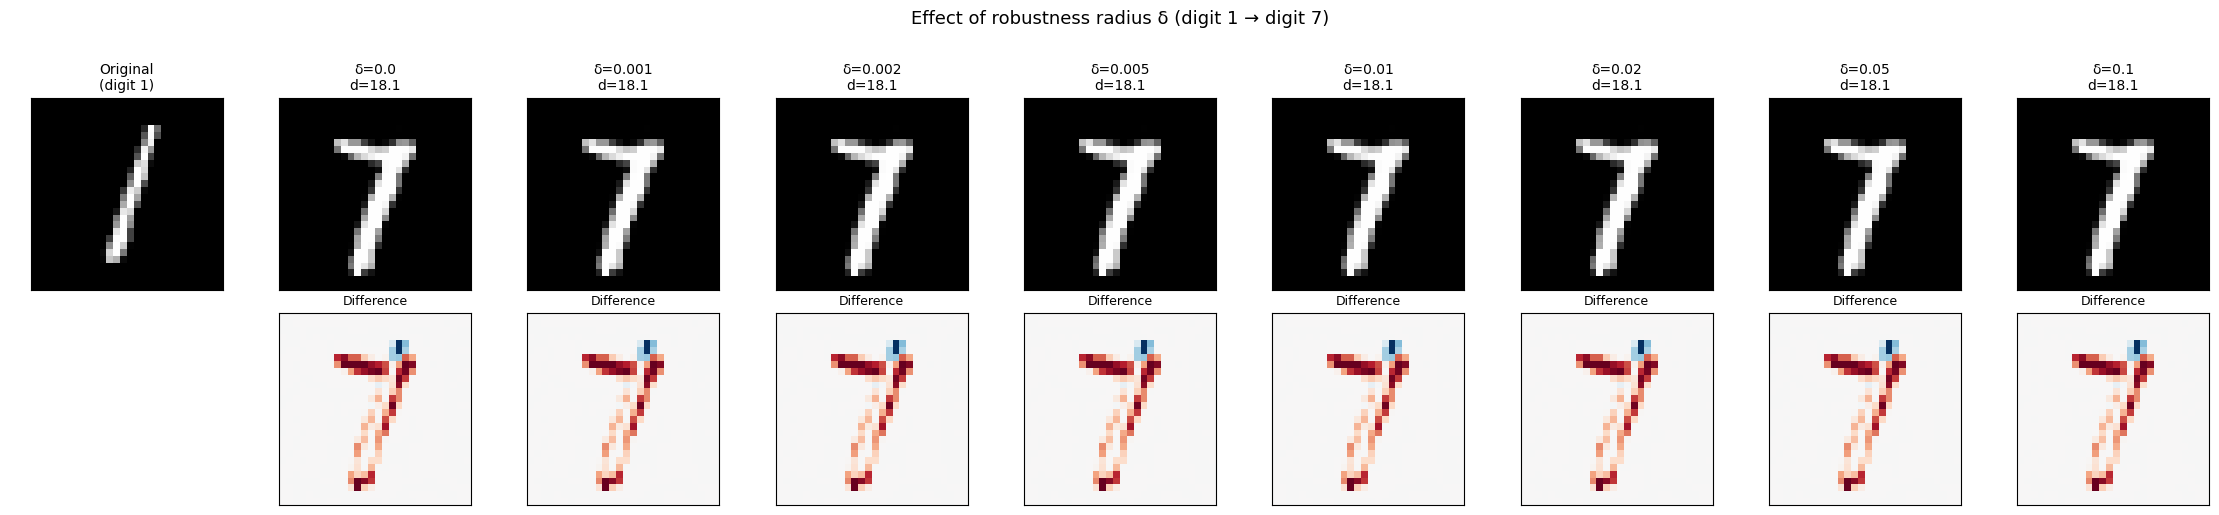

In [12]:
# Visualize the effect of increasing delta on a counterfactual
x_query = atlas.bounds[1]['X'][0]
target = 7

fig, axes = plt.subplots(2, len(delta_values) + 1, figsize=(2.5 * (len(delta_values) + 1), 5))

# Show original
axes[0, 0].imshow(denormalize(x_query), cmap='gray', vmin=0, vmax=1)
axes[0, 0].set_title(f'Original\n(digit 1)', fontsize=10)
axes[1, 0].axis('off')
for row in range(2):
    axes[row, 0].set_xticks([])
    axes[row, 0].set_yticks([])

for col, delta in enumerate(delta_values, 1):
    result = atlas.find_counterfactual(x_query, target, method='bvh', delta=delta)
    for row in range(2):
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])

    if result.success:
        axes[0, col].imshow(denormalize(result.x_cf), cmap='gray', vmin=0, vmax=1)
        axes[0, col].set_title(f'δ={delta}\nd={result.distance:.1f}', fontsize=10)

        diff = (result.x_cf - x_query).reshape(28, 28)
        vmax = max(abs(diff.min()), abs(diff.max()))
        if vmax > 0:
            axes[1, col].imshow(diff, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        else:
            axes[1, col].imshow(diff, cmap='RdBu_r')
        axes[1, col].set_title('Difference', fontsize=9)
    else:
        axes[0, col].set_title(f'δ={delta}\n(failed)', fontsize=10)
        axes[0, col].axis('off')
        axes[1, col].axis('off')

fig.suptitle(f'Effect of robustness radius δ (digit 1 → digit {target})', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 9 – Benchmark: BVH vs k-NN Search

In 784 dimensions, each QP solve is expensive (~0.5–2s). BVH pruning is critical for practical use.

In [ ]:
import time

n_test = 5
test_queries = atlas.bounds[0]['X'][:n_test]
target = 9
n_polytopes = len(atlas.bounds[target]['X'])

print(f'Benchmarking {n_test} queries (digit 0 -> digit {target})')
print(f'Total polytopes in target class: {n_polytopes}')
print('=' * 60)

bvh_qps, knn_qps = [], []
bvh_times, knn_times = [], []

for i, x0 in enumerate(test_queries):
    # BVH
    t0 = time.time()
    result_bvh = atlas.find_counterfactual(x0, target, method='bvh')
    t_bvh = time.time() - t0

    # k-NN (k = all polytopes)
    t0 = time.time()
    result_knn = atlas.find_counterfactual(x0, target, method='knn', k=n_polytopes)
    t_knn = time.time() - t0

    bvh_qps.append(result_bvh.n_qp_solved)
    knn_qps.append(result_knn.n_qp_solved)
    bvh_times.append(t_bvh)
    knn_times.append(t_knn)

    match = np.isclose(result_bvh.distance, result_knn.distance, atol=1e-3)
    print(f'Query {i}: BVH {result_bvh.n_qp_solved:3d} QPs ({t_bvh:5.1f}s) | '
          f'k-NN {result_knn.n_qp_solved:3d} QPs ({t_knn:5.1f}s) | '
          f'dist={result_bvh.distance:.2f} {"✓" if match else "✗"}')

print('=' * 60)
print(f'Avg QPs:  BVH = {np.mean(bvh_qps):.1f},  k-NN = {np.mean(knn_qps):.1f}  '
      f'({np.mean(knn_qps)/np.mean(bvh_qps):.1f}x fewer with BVH)')
print(f'Avg time: BVH = {np.mean(bvh_times):.1f}s,  k-NN = {np.mean(knn_times):.1f}s  '
      f'({np.mean(knn_times)/np.mean(bvh_times):.1f}x speedup with BVH)')

Benchmarking 5 queries (digit 0 -> digit 9)
Total polytopes in target class: 1009


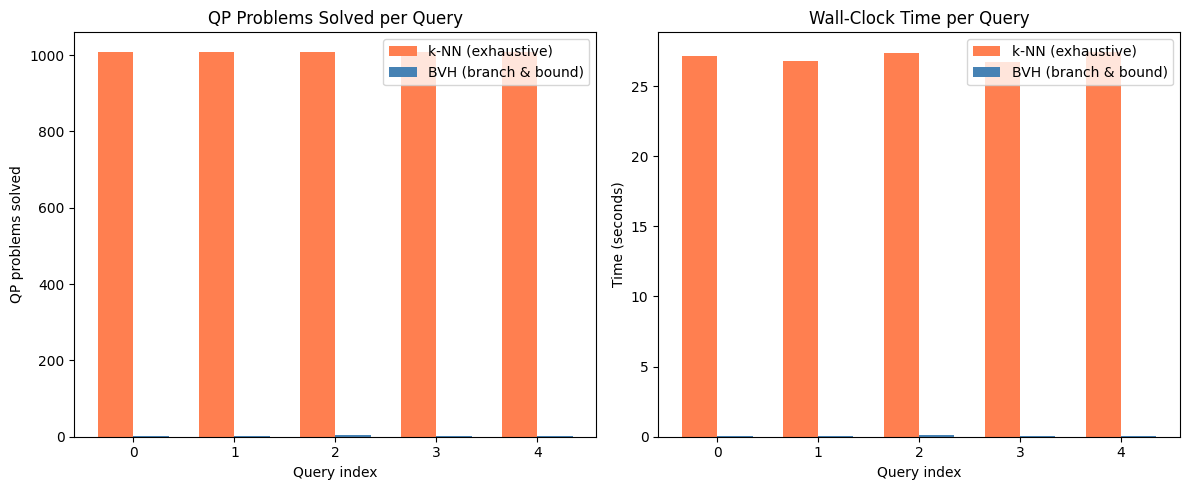

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# QPs comparison
ax = axes[0]
x_pos = np.arange(n_test)
width = 0.35
ax.bar(x_pos - width/2, knn_qps, width, label='k-NN (exhaustive)', color='coral')
ax.bar(x_pos + width/2, bvh_qps, width, label='BVH (branch & bound)', color='steelblue')
ax.set_xlabel('Query index')
ax.set_ylabel('QP problems solved')
ax.set_title('QP Problems Solved per Query')
ax.legend()

# Time comparison
ax = axes[1]
ax.bar(x_pos - width/2, knn_times, width, label='k-NN (exhaustive)', color='coral')
ax.bar(x_pos + width/2, bvh_times, width, label='BVH (branch & bound)', color='steelblue')
ax.set_xlabel('Query index')
ax.set_ylabel('Time (seconds)')
ax.set_title('Wall-Clock Time per Query')
ax.legend()

plt.tight_layout()
plt.show()

## 10 – Counterfactual Quality Metrics

In [ ]:
from sklearn.neighbors import LocalOutlierFactor, KernelDensity
import pandas as pd

# Generate counterfactuals for several source/target pairs and compute metrics
source_digits = [0, 1, 3, 7]
n_queries_per = 5

rows = []
for source_class in source_digits:
    queries = atlas.bounds[source_class]['X'][:n_queries_per]

    for target_class in range(10):
        if target_class == source_class:
            continue

        target_data = atlas.bounds[target_class]['X']
        n_neighbors = min(10, len(target_data) - 1)
        lof = LocalOutlierFactor(n_neighbors=n_neighbors, novelty=True)
        lof.fit(target_data)

        for i, x_q in enumerate(queries):
            result = atlas.find_counterfactual(x_q, target_class, method='bvh')
            if not result.success:
                continue

            x_cf = result.x_cf
            diff = x_cf - x_q

            rows.append({
                'source': source_class,
                'target': target_class,
                'query_idx': i,
                'l2_distance': np.linalg.norm(diff),
                'linf_distance': np.max(np.abs(diff)),
                'l1_distance': np.sum(np.abs(diff)),
                'n_pixels_changed': int(np.sum(np.abs(diff) > 1e-3)),
                'sparsity': np.sum(np.abs(diff) > 1e-3) / 784,
                'lof_score': -lof.score_samples(x_cf.reshape(1, -1))[0],
                'n_qp_solved': result.n_qp_solved
            })

metrics_df = pd.DataFrame(rows)
print(f'Generated {len(metrics_df)} counterfactuals\n')
metrics_df.head(10)

Generated 180 counterfactuals



,source,target,query_idx,l2_distance,linf_distance,l1_distance,n_pixels_changed,sparsity,lof_score,n_qp_solved
0,0,1,0,30.971285,3.222332,365.480342,229,0.292092,2.215917,4
1,0,1,1,32.006213,3.230675,401.921276,203,0.258929,1.289888,13
2,0,1,2,31.321585,3.219119,379.417757,194,0.247449,1.289929,2
3,0,1,3,39.110988,3.227239,550.587051,272,0.346939,2.215936,6
4,0,1,4,32.430403,3.224691,403.486847,230,0.293367,2.215926,4
5,0,2,0,25.688839,3.213469,278.050099,204,0.260204,1.100307,1
6,0,2,1,23.629621,3.223883,262.419828,210,0.267857,1.027697,1
7,0,2,2,28.094191,3.216672,328.275713,223,0.284439,1.127999,3
8,0,2,3,28.573280,3.219962,349.888255,239,0.304847,1.129868,2
9,0,2,4,25.202812,3.210247,278.393762,234,0.298469,1.032497,2


INFO     18:36:51     [category.py:224] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO     18:36:51     [category.py:224] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO     18:36:51     [category.py:224] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO     18:36:51     [category.py:224] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO     18:36:51     [category.py:224] Using categorical units to plot a list o

/home/gabrielepintus/.local/lib/python3.13/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/home/gabrielepintus/.local/lib/python3.13/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/home/gabrielepintus/.local/lib/python3.13/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/home/gabrielepintus/.local/lib/python3.13/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


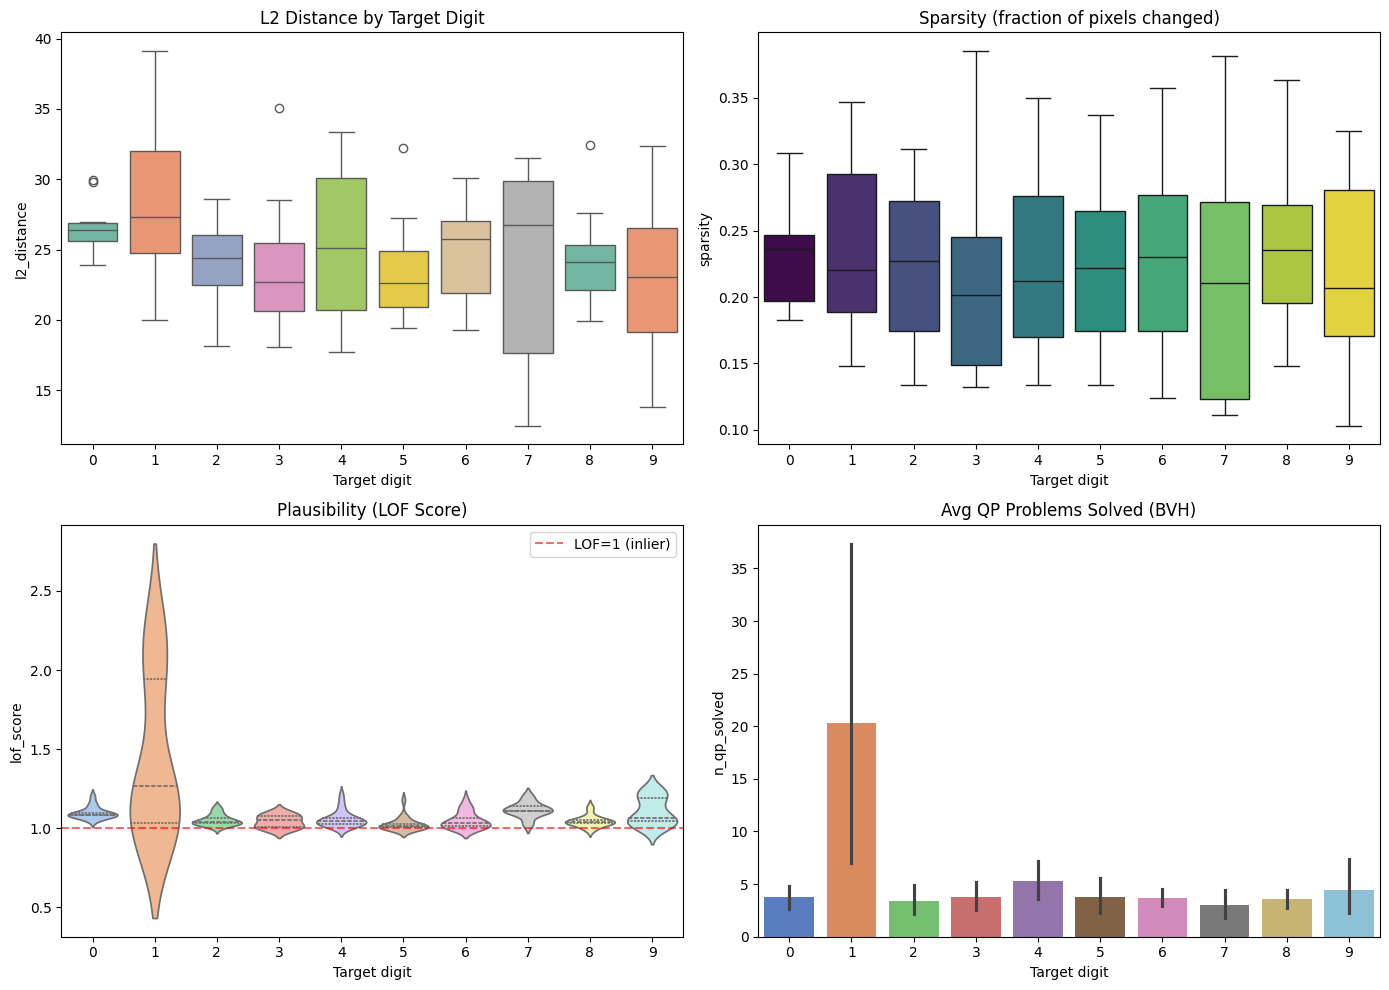

In [ ]:
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# L2 distance by target class
sns.boxplot(ax=axes[0, 0], x='target', y='l2_distance', data=metrics_df,
            hue='target', palette='Set2', legend=False)
axes[0, 0].set_title('L2 Distance by Target Digit')
axes[0, 0].set_xlabel('Target digit')

# Sparsity (fraction of pixels changed)
sns.boxplot(ax=axes[0, 1], x='target', y='sparsity', data=metrics_df,
            hue='target', palette='viridis', legend=False)
axes[0, 1].set_title('Sparsity (fraction of pixels changed)')
axes[0, 1].set_xlabel('Target digit')

# LOF plausibility
sns.violinplot(ax=axes[1, 0], x='target', y='lof_score', data=metrics_df,
               hue='target', palette='pastel', legend=False, inner='quart')
axes[1, 0].axhline(1.0, color='red', linestyle='--', alpha=0.6, label='LOF=1 (inlier)')
axes[1, 0].set_title('Plausibility (LOF Score)')
axes[1, 0].set_xlabel('Target digit')
axes[1, 0].legend()

# QPs solved (efficiency)
sns.barplot(ax=axes[1, 1], x='target', y='n_qp_solved', data=metrics_df,
            hue='target', palette='muted', legend=False, estimator='mean')
axes[1, 1].set_title('Avg QP Problems Solved (BVH)')
axes[1, 1].set_xlabel('Target digit')

plt.tight_layout()
plt.show()

## Summary

We demonstrated certified counterfactual generation on MNIST with a CNN classifier:

```python
# Build atlas (offline, ~1-2 min for 200 samples)
atlas = CertCFAtlas(model, dataset, device, cnn=True)
atlas.build(eps=0.01, norm=np.inf)

# Generate counterfactual (online, ~0.5-2s per query)
result = atlas.find_counterfactual(x_query, target_class=3)

# Generate δ-robust counterfactual
result = atlas.find_counterfactual(x_query, target_class=3,
                                    delta=0.001, robust_norm=2)
```

Key observations:
- **Certified validity**: All counterfactuals are guaranteed to be classified as the target digit
- **δ-robustness**: Counterfactuals can be made robust to adversarial perturbations at the cost of slightly larger distances
- **BVH efficiency**: Branch-and-bound pruning dramatically reduces the number of QP solves in 784D
- **Cross-norm robustness**: The robustness norm (e.g. L2) can differ from the certification norm (L∞)